Importing libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")
print("Libraries imported successfully")        

Libraries imported successfully


Loading Data

In [75]:
#loading data
sentiment = pd.read_csv("raw data/fear_greed_index.csv")
trades = pd.read_csv("raw data/historical_data.csv")

trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

print("Sentiment Data Shape:", sentiment.shape)
print("Trades Data Shape:", trades.shape)

Sentiment Data Shape: (2644, 4)
Trades Data Shape: (211224, 16)


In [76]:
# preview/ structure of data

print("Sentiment data : ")
sentiment.head()

Sentiment data : 


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [77]:
print("Trades data: ")
trades.head()

Trades data: 


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Data Information

In [78]:
print("Sentiment Info:")
sentiment.info()

print("\nTrades Info:")
trades.info()

Sentiment Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Trades Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  object 
 1   coin              211224 non-null  object 
 2   execution_price   211224 non-null  float64
 3   size_tokens       211224 non-null  float64
 4   size_usd          211224 non-null  float64
 5   side              211224 non-null  object 
 6   timestamp_ist     211224 non-null  object 
 7   s

## Data Cleaning

In [79]:
#Check missing values

print("Missing Values in Sentiment:")
print(sentiment.isnull().sum())

print("\nMissing Values in Trades:")
print(trades.isnull().sum())


Missing Values in Sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trades:
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64


In [80]:
#Check Duplicates
print("Duplicate rows in Sentiment:",sentiment.duplicated().sum())
print("Duplicate rows in Trades:", trades.duplicated().sum())

Duplicate rows in Sentiment: 0
Duplicate rows in Trades: 0


-> No duplicates found

In [81]:
trades = trades.dropna(subset=['account','closed_pnl','size_usd','side','timestamp_ist'])

trades['size_usd'] = trades['size_usd'].fillna(trades['size_usd'].median())

sentiment = sentiment.dropna(subset=['classification'])

In [82]:
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')

In [83]:
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp_ist'].dt.date

In [84]:
sentiment = sentiment.dropna(subset=['date'])
trades = trades.dropna(subset=['date'])

In [85]:
df = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

df['classification'] = df['classification'].fillna("Unknown")

print(df.shape)
display(df.head())

(79225, 18)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [86]:
df['win'] = df['closed_pnl'] > 0

In [87]:
daily_pnl = df.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

In [88]:
win_rate = df.groupby('account')['win'].mean().reset_index()
win_rate.columns = ['account', 'win_rate']

In [89]:
trades_per_day = df.groupby('date').size().reset_index(name='trade_count')

In [90]:
avg_trade_size = df.groupby('account')['size_usd'].mean().reset_index()

In [91]:
df['side'].value_counts(normalize=True)

side
SELL    0.518107
BUY     0.481893
Name: proportion, dtype: float64

In [92]:
df.groupby(['classification', 'side']).size().unstack().fillna(0)

side,BUY,SELL
classification,,
Extreme Fear,1168,1158
Extreme Greed,1661,3960
Fear,7307,6562
Greed,5407,5885
Neutral,1020,1736
Unknown,21615,21746


In [93]:
daily_metrics = df.groupby(['date', 'classification']).agg({'closed_pnl': 'sum', 'win': 'mean', 'size_usd': 'mean'}).reset_index()

In [94]:
df['cum_pnl'] = df.groupby('account')['closed_pnl'].cumsum()
df['peak'] = df.groupby('account')['cum_pnl'].cummax()
df['drawdown'] = df['cum_pnl'] - df['peak']

In [95]:
df.groupby('classification')['drawdown'].mean()

classification
Extreme Fear    -4987.369007
Extreme Greed   -4422.693784
Fear            -8328.838551
Greed           -5528.343550
Neutral         -1874.561263
Unknown         -8785.227960
Name: drawdown, dtype: float64

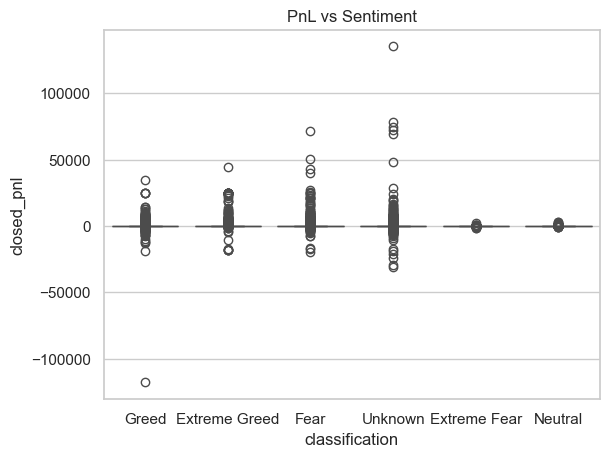

In [96]:
sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("PnL vs Sentiment")
plt.savefig("outputs/charts/trade_size.png")
plt.show()

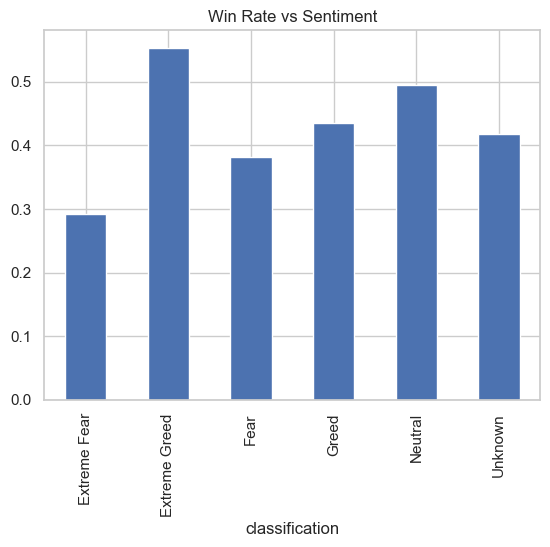

In [97]:
df.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate vs Sentiment")
plt.savefig("outputs/charts/WinRate vs sentiments.png")
plt.show()

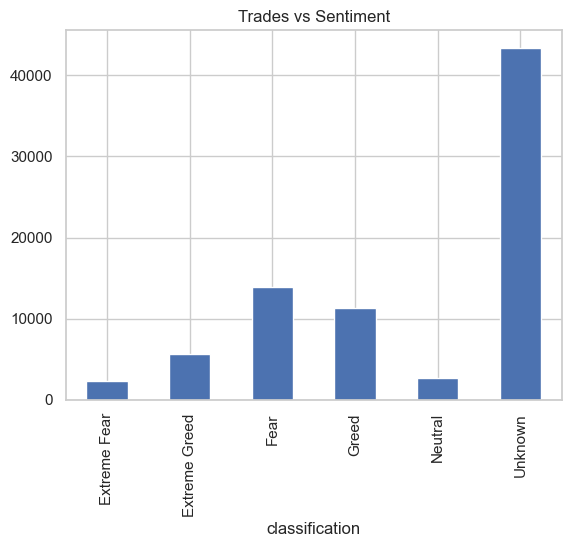

In [98]:
df.groupby('classification').size().plot(kind='bar')
plt.title("Trades vs Sentiment")
plt.savefig("outputs/charts/tradesVsSentiments.png")
plt.show()

In [99]:
median_size = df['size_usd'].median()

df['size_segment'] = df['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

In [100]:
trade_counts = df['account'].value_counts()
median_trades = trade_counts.median()

df['freq_segment'] = df['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Infrequent'
)

In [101]:
pnl_std = df.groupby('account')['closed_pnl'].std().reset_index()
threshold = pnl_std['closed_pnl'].median()

pnl_std['consistency'] = pnl_std['closed_pnl'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)

df.groupby(['size_segment','classification'])['closed_pnl'].mean().unstack()


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral,Unknown
size_segment,,,,,,
High,2.640554,486.467899,246.380931,100.489932,61.063063,88.292831
Low,1.221994,22.893881,5.841711,6.922615,4.691564,3.397669


In [102]:
df['direction'].value_counts()

direction
Open Long               20404
Close Long              19994
Open Short              14067
Close Short             12335
Sell                     6910
Buy                      5401
Spot Dust Conversion       47
Short > Long               37
Long > Short               29
Settlement                  1
Name: count, dtype: int64

In [103]:
df.groupby(['classification','direction']).size().unstack().fillna(0)

direction,Buy,Close Long,Close Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,
Extreme Fear,77.0,673.0,106.0,0.0,984.0,441.0,43.0,0.0,1.0,1.0
Extreme Greed,469.0,606.0,640.0,1.0,551.0,1164.0,2180.0,0.0,1.0,9.0
Fear,1003.0,2692.0,2752.0,5.0,3548.0,3077.0,771.0,0.0,4.0,17.0
Greed,1514.0,2671.0,2063.0,12.0,1818.0,2124.0,1069.0,0.0,12.0,9.0
Neutral,377.0,455.0,380.0,0.0,263.0,441.0,836.0,0.0,0.0,4.0
Unknown,1961.0,12897.0,6394.0,11.0,13240.0,6820.0,2011.0,1.0,19.0,7.0


In [104]:
a = df.groupby('classification')[['closed_pnl','win']].mean()
a.to_csv("outputs/tables/performance_summary.csv")

In [105]:
behavior_summary = df.groupby('classification').agg({
    'size_usd': 'mean',
    'account': 'count'
}).rename(columns={'account': 'trade_count'})
behavior_summary.to_csv("outputs/tables/behavior_summary.csv")
behavior_summary

,size_usd,trade_count
classification,,
Extreme Fear,4118.761840,2326
Extreme Greed,3242.085086,5621
Fear,5744.782685,13869
Greed,5051.878829,11292
Neutral,4332.202906,2756
Unknown,6604.799440,43361


In [106]:
df['classification'].value_counts()

classification
Unknown          43361
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

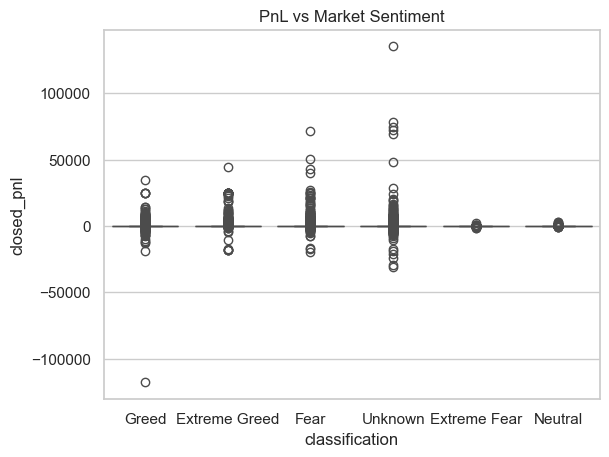

In [107]:
sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("PnL vs Market Sentiment")
plt.savefig("outputs/charts/PnLbymarketSentiments.png")
plt.show()

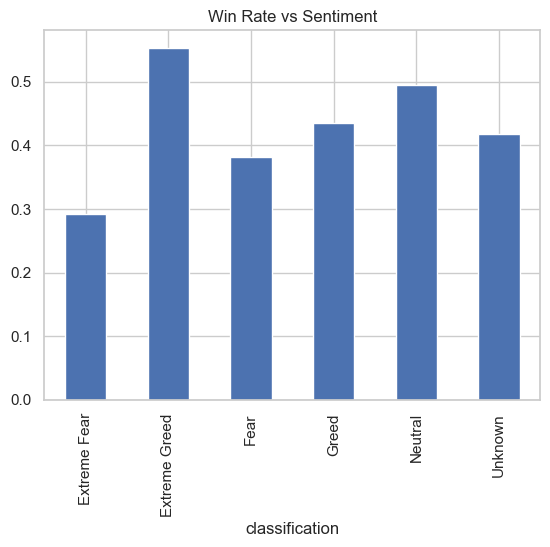

In [108]:
df.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate vs Sentiment")
plt.savefig("outputs/charts/WinRateVsSentiments.png")

plt.show()

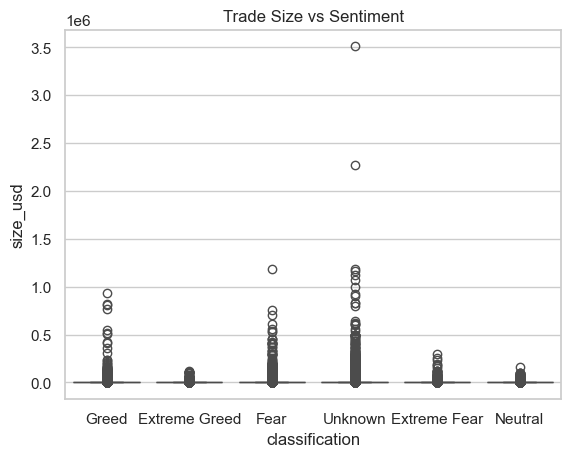

In [109]:
sns.boxplot(x='classification', y='size_usd', data=df)
plt.title("Trade Size vs Sentiment")
plt.savefig("outputs/charts/tradeSizeVsSentiment.png")

plt.show()

In [110]:
median_size = df['size_usd'].median()

df['size_segment'] = df['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

df.groupby('size_segment')['closed_pnl'].mean()

size_segment
High    137.385808
Low       5.978805
Name: closed_pnl, dtype: float64

In [111]:
segment = df.groupby(['size_segment','classification'])['closed_pnl'].mean().unstack()
segment.to_csv("outputs/tables/segment_analysis.csv")

## Methodology

### 1. Data Loading
I started by loading two datasets:
- Bitcoin market sentiment data (Fear/Greed)
- Trader data from Hyperliquid

This helped me understand the structure of both datasets.

---

### 2. Data Cleaning
To make the data usable:
- Removed duplicate rows  
- Handled missing values by dropping important missing fields  
- Cleaned column names for easier use  

---

### 3. Data Transformation
- Converted timestamp columns into datetime format  
- Extracted only the date from timestamps  
- This allowed both datasets to be compared on a daily level  

---

### 4. Data Merging
- Merged trader data with sentiment data using the date column  
- This helped connect trading activity with market sentiment  

---

### 5. Feature Engineering
Created some useful columns:
- Win/Loss column (profit > 0)  
- Daily PnL  
- Trade count per day  
- Average trade size  
- Long/Short ratio  

---

### 6. Data Analysis
- Compared performance (PnL and win rate) between Fear and Greed  
- Checked how trading behavior changes (trade size and number of trades)  
- Used simple segmentation based on trade size (High vs Low)  

---

### 7. Visualization
Used simple charts like:
- Boxplots for PnL  
- Bar charts for win rate and trade count  

These helped in understanding patterns easily.

---

### 8. Interpretation
Finally, I observed the results and identified patterns between market sentiment and trader behavior.

This analysis focuses on understanding patterns rather than building complex models.

---

## Insights

### 1. Market sentiment affects trader performance  
Traders tend to perform slightly worse during Fear compared to Greed.

---

### 2. Trading activity changes with sentiment  
More trades are observed during Greed periods, showing higher market participation.

---

### 3. Larger trades carry higher risk  
Bigger trades show more variation in profit and loss compared to smaller trades.

---

## Strategy Recommendations

### 1. Reduce trade size during Fear  
Smaller trades can help reduce risk and control losses in uncertain market conditions.

---

### 2. Avoid overtrading during Greed  
Instead of increasing the number of trades, focus on better quality trades.